# MultiVI on gastrulation multiome atlas

In [2]:
import gzip
import os
import tempfile
from pathlib import Path

import numpy as np
#import pooch
import scanpy as sc
import scvi
#import seaborn as sns
import torch
import pandas as pd

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


In [3]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("CUDA Device Name:", torch.cuda.get_device_name(0))

CUDA Available: True
CUDA Device Count: 1
CUDA Device Name: NVIDIA A100-SXM4-80GB


In [4]:
atac = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/anndata/PeakMatrix/PeakMatrix_anndata.h5ad')

In [5]:
atac

AnnData object with n_obs × n_vars = 57536 × 192251
    obs: 'BlacklistRatio', 'nDiFrags', 'nFrags', 'nMonoFrags', 'nMultiFrags', 'NucleosomeRatio', 'PassQC', 'PromoterRatio', 'ReadsInBlacklist', 'ReadsInPromoter', 'ReadsInTSS', 'Sample', 'TSSEnrichment', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype.mapped', 'celltype.score', 'closest.cell', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'ReadsInPeaks', 'FRIP'
    var: 'idx'
    uns: 'celltype_colors', 'stage_colors'

In [6]:
rna = sc.read_h5ad('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/rna/anndata.h5ad')

In [7]:
rna

AnnData object with n_obs × n_vars = 65420 × 32285
    obs: 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype', 'celltype.score', 'closest.cell'
    var: 'gene'

In [8]:
meta = pd.read_csv('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/results/atac/archR/qc/sample_metadata_after_qc.txt.gz', sep='\t', compression='gzip')

In [9]:
meta.columns

Index(['cell', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA',
       'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage',
       'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype',
       'celltype.score', 'closest.cell', 'TSSEnrichment_atac',
       'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac',
       'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC'],
      dtype='object')

In [10]:
meta = meta[(meta['pass_atacQC'] == True) & (meta['pass_rnaQC'] == True) & (meta['doublet_call'] == False) &
    (meta['sample'] != 'E8.5_CRISPR_T_KO') & (meta['sample'] != 'E8.5_CRISPR_T_WT')]

In [11]:
meta.shape

(45713, 22)

In [12]:
meta.index = meta.cell

In [13]:
common_cells = list(set(meta.cell) & set(rna.obs_names) & set(atac.obs_names))
len(common_cells)

45214

In [14]:
meta = meta[meta.index.isin(common_cells)]

In [15]:
meta = meta.reindex(common_cells)

In [16]:
rna = rna[common_cells, :]
atac = atac[common_cells, :]

In [17]:
rna.obs = meta
atac.obs = meta

In [18]:
rna.X

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 189523578 stored elements and shape (45214, 32285)>

In [19]:
import scipy.sparse as sp

In [20]:
matrix_combined = sp.hstack([rna.X, atac.X])

In [21]:
adata = sc.AnnData(matrix_combined)

In [22]:
adata.obs = meta

In [23]:
rna.var['ID'] = rna.var.index
rna.var['modality'] = 'Gene Expression'
rna.var['chr'] = 'chr'
rna.var['start'] = 'start'
rna.var['end'] = 'end'
rna.var = rna.var.drop(columns=['gene'])

atac.var['ID'] = atac.var.index
atac.var['modality'] = 'Peaks'
atac.var['chr'] = 'chr'
atac.var['start'] = 'start'
atac.var['end'] = 'end'
atac.var = atac.var.drop(columns=['idx'])

In [24]:
var_combined = pd.concat([rna.var, atac.var], axis=0, ignore_index=False)

In [25]:
adata.var = var_combined

In [26]:
adata

AnnData object with n_obs × n_vars = 45214 × 224536
    obs: 'cell', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage', 'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype', 'celltype.score', 'closest.cell', 'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC'
    var: 'ID', 'modality', 'chr', 'start', 'end'

In [27]:
adata = adata[:, adata.var["modality"].argsort()].copy()
adata.var

,ID,modality,chr,start,end
Xkr4,Xkr4,Gene Expression,chr,start,end
Gm48665,Gm48665,Gene Expression,chr,start,end
4930473H19Rik,4930473H19Rik,Gene Expression,chr,start,end
3200001D21Rik,3200001D21Rik,Gene Expression,chr,start,end
Adck1,Adck1,Gene Expression,chr,start,end
...,...,...,...,...,...
chr15:66980212-66980812,chr15:66980212-66980812,Peaks,chr,start,end
chr15:66984054-66984654,chr15:66984054-66984654,Peaks,chr,start,end
chr15:66984684-66985284,chr15:66984684-66985284,Peaks,chr,start,end
chr15:66932276-66932876,chr15:66932276-66932876,Peaks,chr,start,end


In [28]:
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))

In [29]:
print(adata.shape)

(45214, 198496)


In [30]:
adata.obs.columns

Index(['cell', 'barcode', 'sample', 'nFeature_RNA', 'nCount_RNA',
       'mitochondrial_percent_RNA', 'ribosomal_percent_RNA', 'stage',
       'genotype', 'pass_rnaQC', 'doublet_score', 'doublet_call', 'celltype',
       'celltype.score', 'closest.cell', 'TSSEnrichment_atac',
       'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac',
       'nFrags_atac', 'BlacklistRatio_atac', 'pass_atacQC'],
      dtype='object')

In [31]:
adata.X = adata.X.tocsr()

In [32]:
scvi.model.MULTIVI.setup_anndata(adata, 
                                 batch_key='sample'#, 
                                # continuous_covariate_keys=['nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA',
                                #                           'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac']
                                )

/tmp/ipykernel_391069/1889420568.py:1: DeprecationWarning: MULTIVI is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  scvi.model.MULTIVI.setup_anndata(adata,


In [32]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
    n_latent = 40
)
model.view_anndata_setup()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'sample',
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   9    │
│         n_cells          │ 45214  │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│      n_size_factor       │   0    │
│          n_vars          │ 198496 │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ E7.5_rep1  │          0          │
│                     │ E7.5_rep2  │          1          │
│                     │ E7.75_rep1 │          2          │
│                     │ E8.0_rep1  │          3          │
│                     │ E8.0_rep2  │          4          │
│                     │ E8.5_rep1  │          5          │
│                     │ E8.5_rep2  │          6          │
│                     │ E8.75_rep1 │          7          │
│                     │ E8.75_rep2 │          8          │
└─────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                   batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃   Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['sample'] │ E7.5_rep1  │          0          │
│                     │ E7.5_rep2  │          1          │
│                     │ E7.75_rep1 │          2          │
│                     │ E8.0_rep1  │          3          │
│                     │ E8.0_rep2  │          4          │
│                     │ E8.5_rep1  │          5          │
│                     │ E8.5_rep2  │          6          │
│                     │ E8.75_rep1 │          7          │
│                     │ E8.75_rep2 │          8          │
└─────────────────────┴────────────┴─────────────────────┘

In [33]:
scvi.settings.dl_num_workers = 31

In [34]:
model.train(max_epochs = 100, early_stopping=True)

/tmp/ipykernel_352099/3929608968.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train(max_epochs = 100, early_stopping=True)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 100/100: 100%|██████████| 100/100 [42:38<00:00, 25.49s/it, v_num=1, train_loss_step=4.58e+4, train_loss_epoch=4.56e+4]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [42:38<00:00, 25.58s/it, v_num=1, train_loss_step=4.58e+4, train_loss_epoch=4.56e+4]


In [35]:
model

MultiVI Model with the following params: 
n_genes: 15631, n_regions: 182865, n_proteins: 0, n_hidden: 128, n_latent: 40, n_layers_encoder: 2, 
n_layers_decoder: 2, dropout_rate: 0.1, latent_distribution: normal, deep injection: False, gene_likelihood: zinb, 
gene_dispersion:gene, Mod.Weights: equal, Mod.Penalty: Jeffreys, protein_dispersion: protein
Training status: Trained

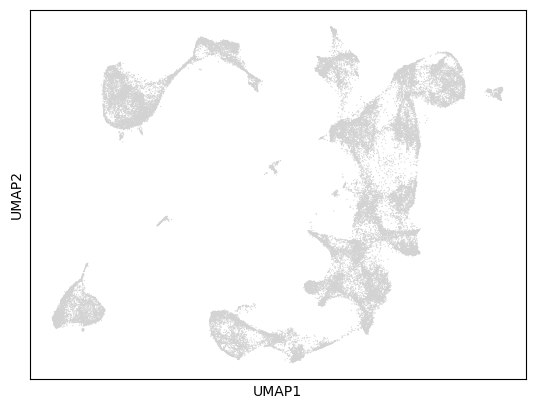

In [36]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 45)
sc.tl.umap(adata, min_dist=0.1)
sc.pl.umap(adata)

In [42]:
imputed_expression = model.get_normalized_expression()

In [43]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [44]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

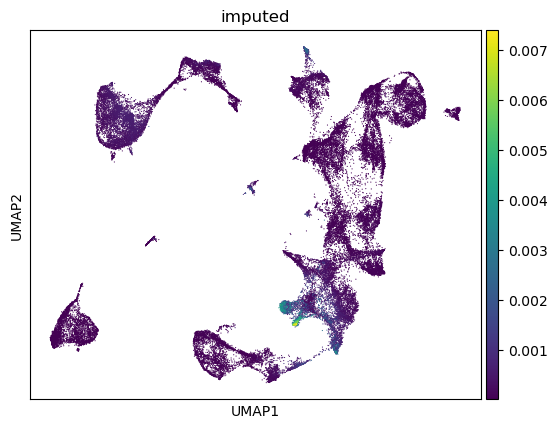

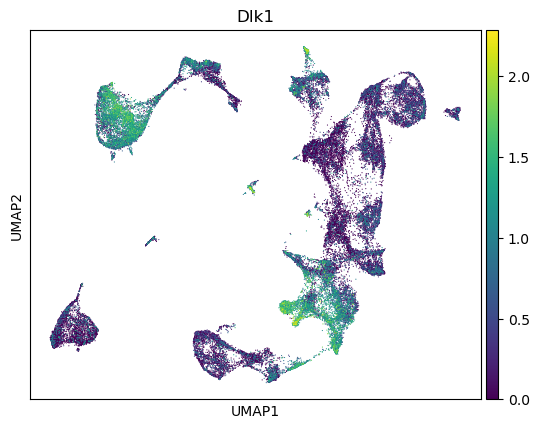

In [50]:
gene = "Dlk1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)

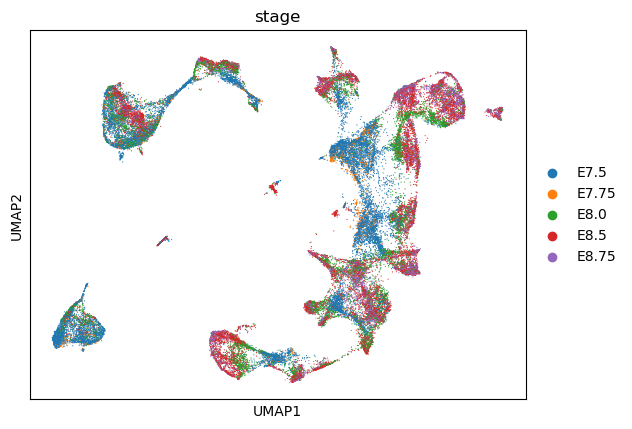

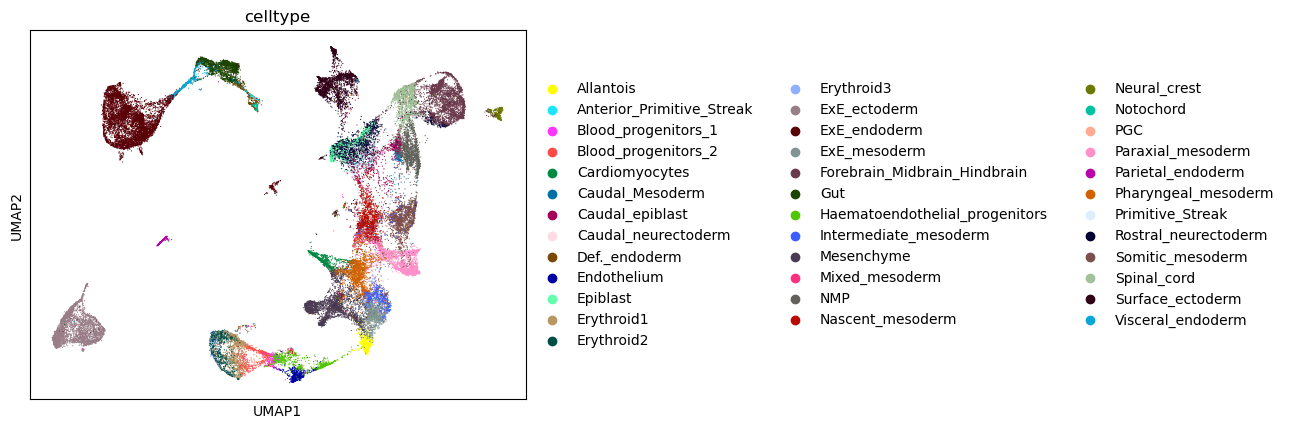

In [51]:
sc.pl.umap(adata, color='stage')
sc.pl.umap(adata, color='celltype')

# Parameter set 2

In [33]:
adata = sc.AnnData(matrix_combined)
adata.var = var_combined
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))
adata.X = adata.X.tocsr()
adata.obs = meta

In [34]:
scvi.model.MULTIVI.setup_anndata(adata, 
                                 batch_key='stage'#, 
                                # continuous_covariate_keys=['nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA',
                                #                           'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac']
                                )

/tmp/ipykernel_391069/232106784.py:1: DeprecationWarning: MULTIVI is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  scvi.model.MULTIVI.setup_anndata(adata,


In [35]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
    n_latent = 40
)
model.view_anndata_setup()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': 'stage',
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': None,
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   5    │
│         n_cells          │ 45214  │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   0    │
│         n_labels         │   1    │
│      n_size_factor       │   0    │
│          n_vars          │ 198496 │
└──────────────────────────┴────────┘

               Data Registry                
┏━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Registry Key ┃    scvi-tools Location    ┃
┡━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      X       │          adata.X          │
│    batch     │ adata.obs['_scvi_batch']  │
│    ind_x     │   adata.obs['_indices']   │
│    labels    │ adata.obs['_scvi_labels'] │
└──────────────┴───────────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['stage'] │    E7.5    │          0          │
│                    │   E7.75    │          1          │
│                    │    E8.0    │          2          │
│                    │    E8.5    │          3          │
│                    │   E8.75    │          4          │
└────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                  batch State Registry                   
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃  Source Location   ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['stage'] │    E7.5    │          0          │
│                    │   E7.75    │          1          │
│                    │    E8.0    │          2          │
│                    │    E8.5    │          3          │
│                    │   E8.75    │          4          │
└────────────────────┴────────────┴─────────────────────┘

In [36]:
scvi.settings.dl_num_workers = 31

In [37]:
model.train(max_epochs = 100, early_stopping=True)

/tmp/ipykernel_391069/3929608968.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train(max_epochs = 100, early_stopping=True)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 100/100: 100%|██████████| 100/100 [42:12<00:00, 25.20s/it, v_num=1, train_loss_step=4.7e+4, train_loss_epoch=4.56e+4] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [42:12<00:00, 25.32s/it, v_num=1, train_loss_step=4.7e+4, train_loss_epoch=4.56e+4]


In [38]:
model

MultiVI Model with the following params: 
n_genes: 15631, n_regions: 182865, n_proteins: 0, n_hidden: 128, n_latent: 40, n_layers_encoder: 2, 
n_layers_decoder: 2, dropout_rate: 0.1, latent_distribution: normal, deep injection: False, gene_likelihood: zinb, 
gene_dispersion:gene, Mod.Weights: equal, Mod.Penalty: Jeffreys, protein_dispersion: protein
Training status: Trained

In [39]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 45)
sc.tl.umap(adata, min_dist=0.1)

In [40]:
imputed_expression = model.get_normalized_expression()

In [41]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [42]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

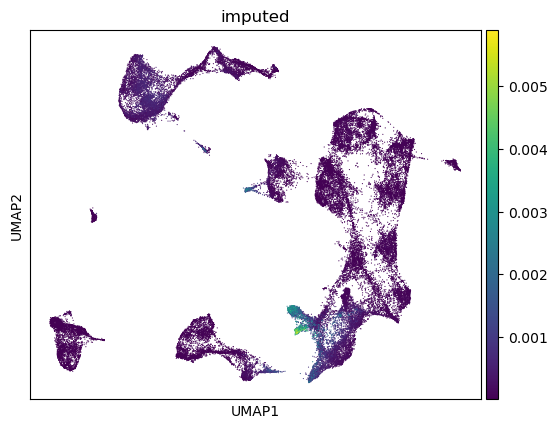

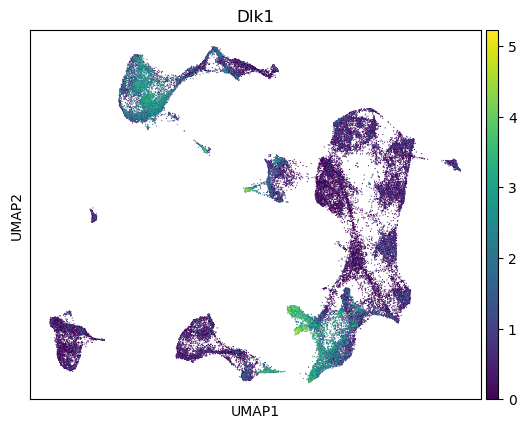

In [43]:
gene = "Dlk1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)

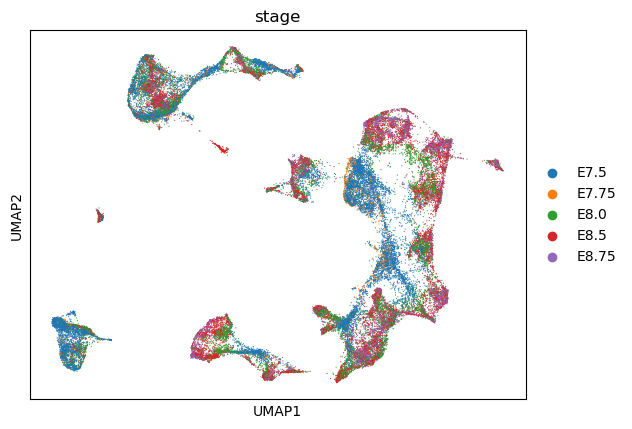

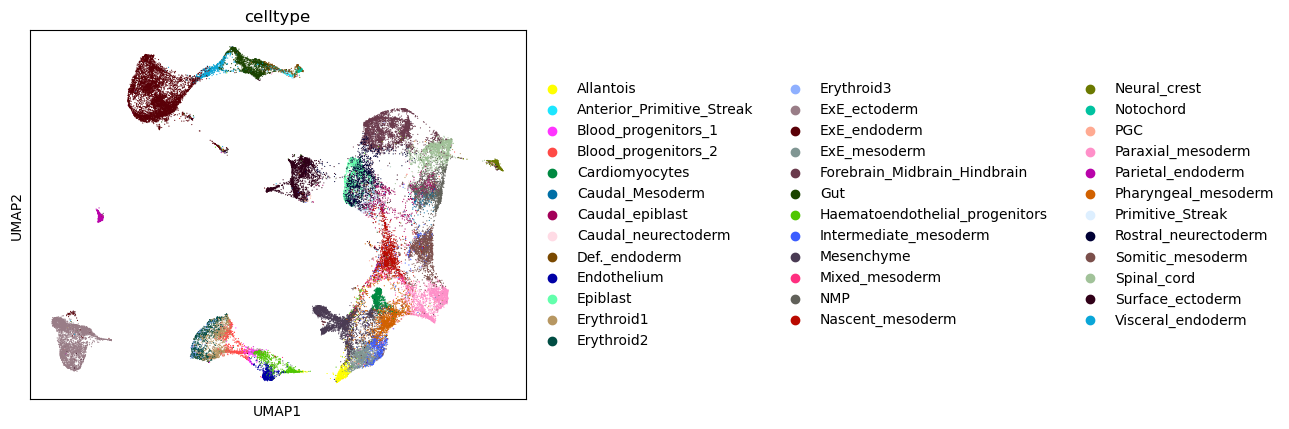

In [44]:
sc.pl.umap(adata, color='stage')
sc.pl.umap(adata, color='celltype')

# Parameter set 3

In [45]:
adata = sc.AnnData(matrix_combined)
adata.var = var_combined
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))
adata.X = adata.X.tocsr()
adata.obs = meta

In [46]:
scvi.model.MULTIVI.setup_anndata(adata, 
                                 continuous_covariate_keys=['nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA']#,
                                #                           'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac']
                                )

/tmp/ipykernel_391069/1671984156.py:1: DeprecationWarning: MULTIVI is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  scvi.model.MULTIVI.setup_anndata(adata,


In [47]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
    n_latent = 40
)
model.view_anndata_setup()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': [
│   │   'nFeature_RNA',
│   │   'nCount_RNA',
│   │   'mitochondrial_percent_RNA',
│   │   'ribosomal_percent_RNA'
│   ],
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   1    │
│         n_cells          │ 45214  │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   4    │
│         n_labels         │   1    │
│      n_size_factor       │   0    │
│          n_vars          │ 198496 │
└──────────────────────────┴────────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │           adata.obs['_indices']           │
│        labels         │         adata.obs['_scvi_labels']         │
└───────────────────────┴───────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

   extra_continuous_covs State Registry   
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       adata.obs['nFeature_RNA']        │
│        adata.obs['nCount_RNA']         │
│ adata.obs['mitochondrial_percent_RNA'] │
│   adata.obs['ribosomal_percent_RNA']   │
└────────────────────────────────────────┘

In [48]:
scvi.settings.dl_num_workers = 31

In [49]:
model.train(max_epochs = 100, early_stopping=True)

/tmp/ipykernel_391069/3929608968.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train(max_epochs = 100, early_stopping=True)
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/scvi/model/_multivi.py:356: UserWarning: Disabling adversarial classifier.
  training_plan = self._training_plan_cls(self.module, **plan_kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 100/100: 100%|██████████| 100/100 [42:50<00:00, 25.60s/it, v_num=1, train_loss_step=4.53e+4, train_loss_epoch=4.63e+4]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [42:50<00:00, 25.70s/it, v_num=1, train_loss_step=4.53e+4, train_loss_epoch=4.63e+4]


In [50]:
model

MultiVI Model with the following params: 
n_genes: 15631, n_regions: 182865, n_proteins: 0, n_hidden: 128, n_latent: 40, n_layers_encoder: 2, 
n_layers_decoder: 2, dropout_rate: 0.1, latent_distribution: normal, deep injection: False, gene_likelihood: zinb, 
gene_dispersion:gene, Mod.Weights: equal, Mod.Penalty: Jeffreys, protein_dispersion: protein
Training status: Trained

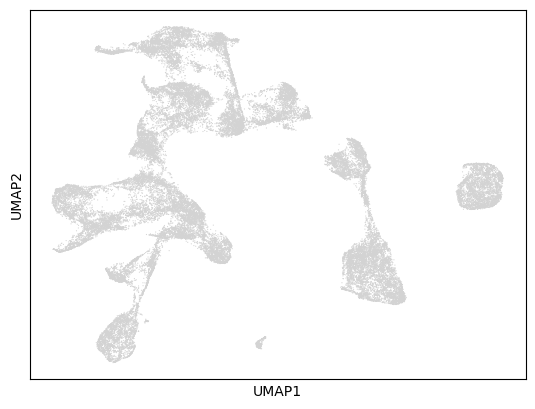

In [51]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 45)
sc.tl.umap(adata, min_dist=0.1)
sc.pl.umap(adata)

In [52]:
imputed_expression = model.get_normalized_expression()

In [53]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [54]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

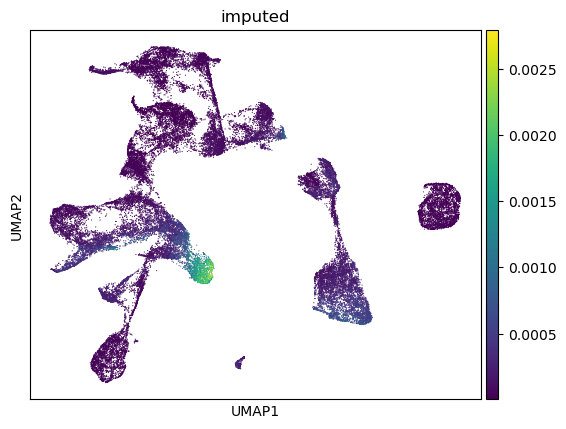

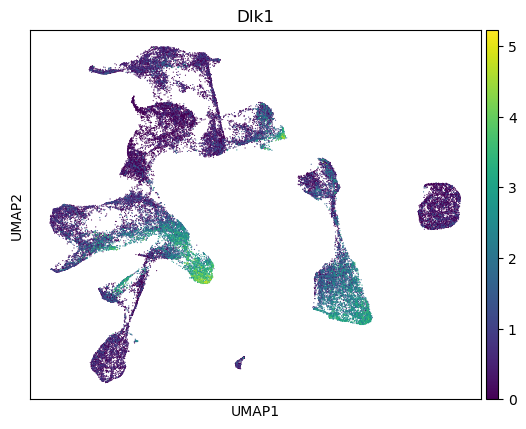

In [55]:
gene = "Dlk1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)

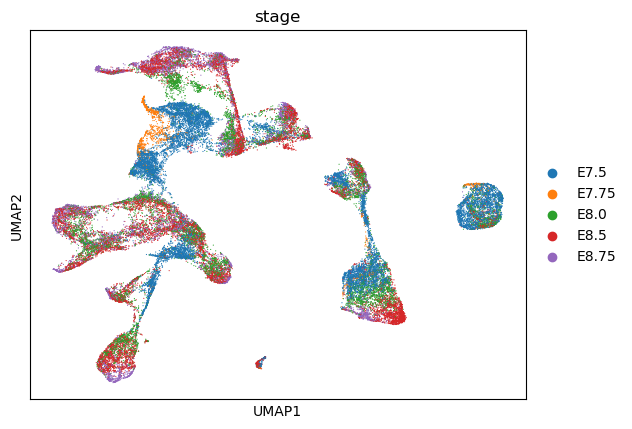

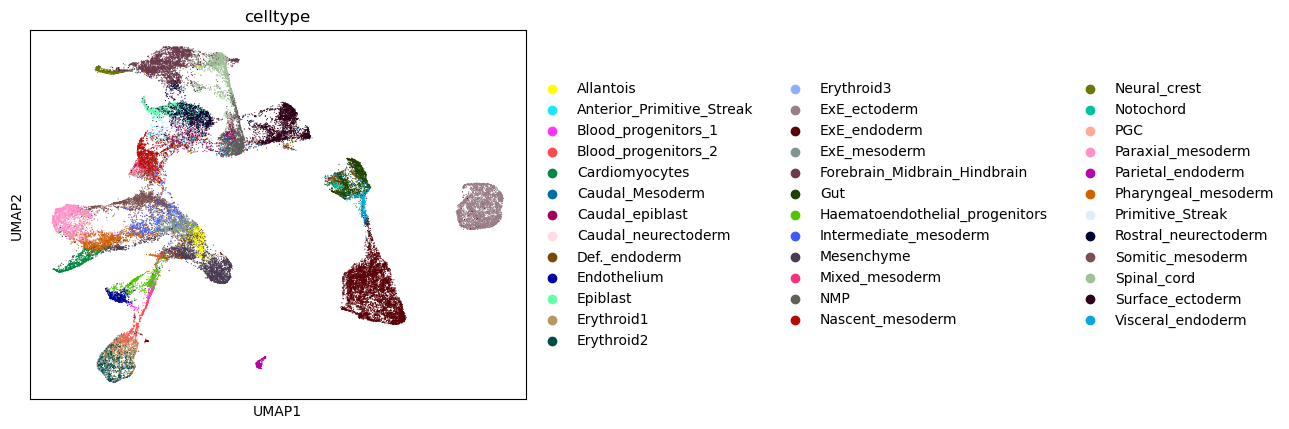

In [56]:
sc.pl.umap(adata, color='stage')
sc.pl.umap(adata, color='celltype')

# Parameter set 4

In [85]:
adata = sc.AnnData(matrix_combined)
adata.var = var_combined
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))
adata.X = adata.X.tocsr()
adata.obs = meta

In [86]:
scvi.model.MULTIVI.setup_anndata(adata, 
                                 #batch_key='sample'#, 
                                 continuous_covariate_keys=['nFeature_RNA', 'nCount_RNA', 'mitochondrial_percent_RNA', 'ribosomal_percent_RNA',
                                                           'TSSEnrichment_atac', 'ReadsInTSS_atac', 'PromoterRatio_atac', 'NucleosomeRatio_atac', 'nFrags_atac', 'BlacklistRatio_atac']
                                )

/tmp/ipykernel_391069/2182975156.py:1: DeprecationWarning: MULTIVI is supposed to work with MuData. the use of anndata is deprecated and will be removed in scvi-tools 1.4. Please use setup_mudata
  scvi.model.MULTIVI.setup_anndata(adata,


In [87]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
    n_latent = 40
)
model.view_anndata_setup()

/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/torch/nn/init.py:511: UserWarning: Initializing zero-element tensors is a no-op
  warnings.warn("Initializing zero-element tensors is a no-op")


Anndata setup with scvi-tools version 1.3.0.

Setup via `MULTIVI.setup_anndata` with arguments:

{
│   'layer': None,
│   'batch_key': None,
│   'size_factor_key': None,
│   'categorical_covariate_keys': None,
│   'continuous_covariate_keys': [
│   │   'nFeature_RNA',
│   │   'nCount_RNA',
│   │   'mitochondrial_percent_RNA',
│   │   'ribosomal_percent_RNA',
│   │   'TSSEnrichment_atac',
│   │   'ReadsInTSS_atac',
│   │   'PromoterRatio_atac',
│   │   'NucleosomeRatio_atac',
│   │   'nFrags_atac',
│   │   'BlacklistRatio_atac'
│   ],
│   'protein_expression_obsm_key': None,
│   'protein_names_uns_key': None
}

         Summary Statistics          
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓
┃     Summary Stat Key     ┃ Value  ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩
│         n_batch          │   1    │
│         n_cells          │ 45214  │
│ n_extra_categorical_covs │   0    │
│ n_extra_continuous_covs  │   10   │
│         n_labels         │   1    │
│      n_size_factor       │   0    │
│          n_vars          │ 198496 │
└──────────────────────────┴────────┘

                            Data Registry                            
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃     Registry Key      ┃            scvi-tools Location            ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│           X           │                  adata.X                  │
│         batch         │         adata.obs['_scvi_batch']          │
│ extra_continuous_covs │ adata.obsm['_scvi_extra_continuous_covs'] │
│         ind_x         │           adata.obs['_indices']           │
│        labels         │         adata.obs['_scvi_labels']         │
└───────────────────────┴───────────────────────────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

                     labels State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃      Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_labels'] │     0      │          0          │
└───────────────────────────┴────────────┴─────────────────────┘

                     batch State Registry                      
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃     Source Location      ┃ Categories ┃ scvi-tools Encoding ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ adata.obs['_scvi_batch'] │     0      │          0          │
└──────────────────────────┴────────────┴─────────────────────┘

   extra_continuous_covs State Registry   
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃            Source Location             ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       adata.obs['nFeature_RNA']        │
│        adata.obs['nCount_RNA']         │
│ adata.obs['mitochondrial_percent_RNA'] │
│   adata.obs['ribosomal_percent_RNA']   │
│    adata.obs['TSSEnrichment_atac']     │
│      adata.obs['ReadsInTSS_atac']      │
│    adata.obs['PromoterRatio_atac']     │
│   adata.obs['NucleosomeRatio_atac']    │
│        adata.obs['nFrags_atac']        │
│    adata.obs['BlacklistRatio_atac']    │
└────────────────────────────────────────┘

In [88]:
scvi.settings.dl_num_workers = 31

In [89]:
model.train(max_epochs = 100, early_stopping=True)

/tmp/ipykernel_391069/3929608968.py:1: DeprecationWarning: `save_best` is deprecated in v1.2 and will be removed in v1.3. Please use `enable_checkpointing` instead. See https://github.com/scverse/scvi-tools/issues/2568 for more details.
  model.train(max_epochs = 100, early_stopping=True)
/home/bt392/miniconda3/envs/multiome2/lib/python3.12/site-packages/scvi/model/_multivi.py:356: UserWarning: Disabling adversarial classifier.
  training_plan = self._training_plan_cls(self.module, **plan_kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 100/100: 100%|██████████| 100/100 [44:44<00:00, 26.74s/it, v_num=1, train_loss_step=4.51e+4, train_loss_epoch=4.67e+4]

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 100/100: 100%|██████████| 100/100 [44:44<00:00, 26.85s/it, v_num=1, train_loss_step=4.51e+4, train_loss_epoch=4.67e+4]


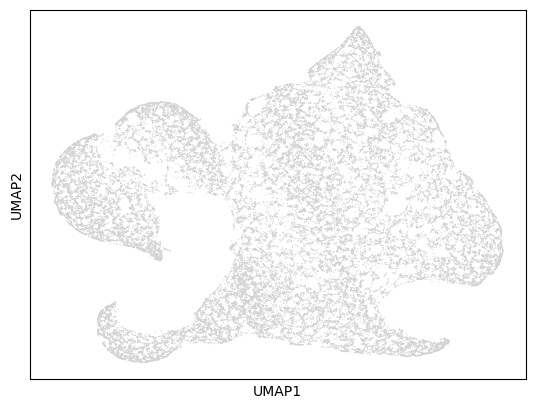

In [91]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 45)
sc.tl.umap(adata, min_dist=0.1)
sc.pl.umap(adata)

In [92]:
imputed_expression = model.get_normalized_expression()

In [93]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [94]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

In [ ]:
gene = "Dlk1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)

In [ ]:
sc.pl.umap(adata, color='stage')
sc.pl.umap(adata, color='celltype')

# Parameter set 5

In [ ]:
adata = sc.AnnData(matrix_combined)
adata.var = var_combined
sc.pp.filter_genes(adata, min_cells=int(adata.shape[0] * 0.01))
adata.X = adata.X.tocsr()
adata.obs = meta

In [ ]:
scvi.model.MULTIVI.setup_anndata(adata, 
                                 batch_key='sample',
                                 categorical_covariate_keys = 'stage')

In [ ]:
model = scvi.model.MULTIVI(
    adata,
    n_genes=(adata.var["modality"] == "Gene Expression").sum(),
    n_regions=(adata.var["modality"] == "Peaks").sum(),
    n_latent = 40
)
model.view_anndata_setup()

In [ ]:
scvi.settings.dl_num_workers = 31

In [ ]:
model.train(max_epochs = 20, early_stopping=True)

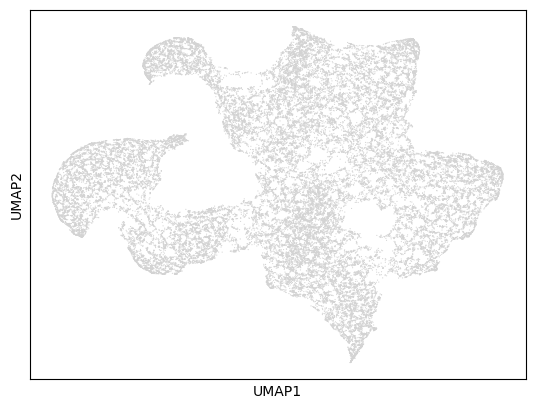

In [74]:
MULTIVI_LATENT_KEY = "X_multivi"

adata.obsm[MULTIVI_LATENT_KEY] = model.get_latent_representation()
sc.pp.neighbors(adata, use_rep=MULTIVI_LATENT_KEY, n_neighbors = 45)
sc.tl.umap(adata, min_dist=0.1)
sc.pl.umap(adata)

In [75]:
imputed_expression = model.get_normalized_expression()

In [76]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [77]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)

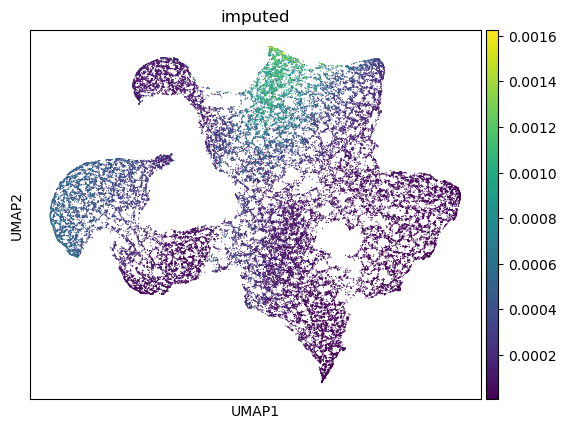

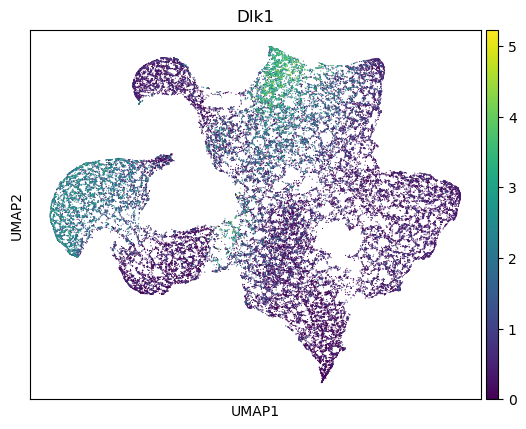

In [78]:
gene = "Dlk1"
gene_idx = np.where(adata.var.index == gene)[0]
adata.obs["imputed"] = imputed_expression.iloc[:, gene_idx]
sc.pl.umap(adata, color="imputed")
sc.pl.umap(adata, color=gene)

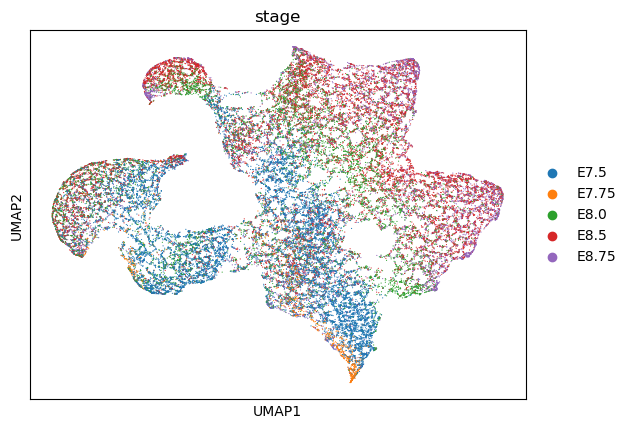

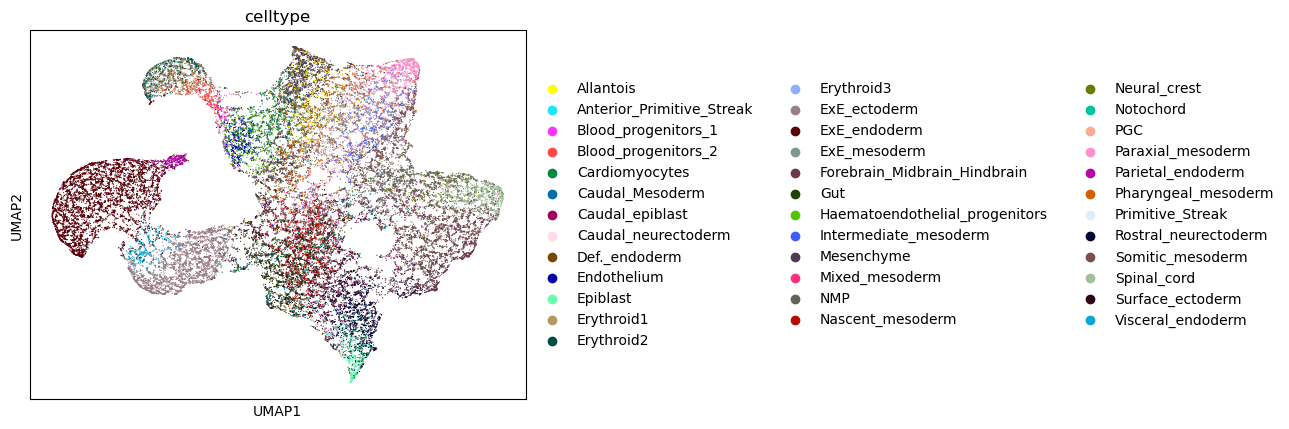

In [79]:
sc.pl.umap(adata, color='stage')
sc.pl.umap(adata, color='celltype')